# RAPID-MFA-22: Hindcasting

## Descriptions

This is the hindcasting model as presented in [Böcher et al., 2025](https://doi.org/10.1016/j.resconrec.2025.108198). It takes two inputs:
- A _current_stocks_ data set with the stock and its age (e.g. current stocks by construction year).
- A _survival curve_ describing the survival/depreciation of inflow cohorts in the stocks as time goes by.

It produces two main model outputs:
- The _inflows_ time series
- The _stocks_ time series
- The _outflows_ time series

And two auxiliary model outputs:
- The _cohorts survival matrix_ table
- The _stock changes_ (net addition to stock) time series

using the hindcasting model equations:
$\text{stock}(y) = \sum_{t=y_0}^{y} \text{cohort}(t)$ (1)

$\text{stock}(y) = \sum_{t=y_0}^{y} [\text{inflow}(t) \times \text{surv}(y - t)]$ (2)

Combining Eqs. (1) and (2), each of the stock’s cohorts is equal to the
surviving inflow from that historical year (Eq. (3)):

$\text{cohort}(t) = \text{inflow}(t) \times \text{surv}(y - t)$ (3)

Which enables to calculate the original value of the inflow of each
historical year t:

$\text{inflow}(t) = \frac{\text{cohort}(t)}{\text{surv}(y - t)}$ (4)

and the flow driven model equations.

### Exogenous variables
__Current stocks:__ number of buildings per construction year, calculated based on [EUBUCCO](https://eubucco.com/files/v0.2) and [Eurostat](https://doi.org/10.2908/CENS_21DWOP_R3) dwelling ages for nuts2 area DE71

__Survival curve:__ Building lifetimes as used in [Böcher et al., 2025](https://doi.org/10.1016/j.resconrec.2025.108198)



### Notes
1. The input data is intended to be replaced with your own data, for example imported from an Excel or CSV file. It should be in an array-like format of any length.
2. The model is split into separate code blocks for ease of understanding. The code blocks can be merged to run as a complete model.
3. Please also read the notes and other details of the notebooks listed in “Relations with other RAPID-MFA notebooks”

### Relations with other RAPID-MFA notebooks
- `RAPID-MFA-1: The flow driven model`: the basic model to calculate flows and stocks based on the hindcasted inflows. 

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Load libraries

In [ ]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats
import math

## 2. Define example input data

In [ ]:
# %% 2. Define example input data

# current stock data per construction year data
input_data = {'construction_year': [1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022], 'building_count': [827, 2418, 3892, 5594, 6982, 8844, 10440, 12190, 13617, 15213, 16571, 18219, 19904, 21547, 23167, 24681, 26614, 27800, 29637, 6296, 6261, 6389, 6383, 6270, 6239, 6327, 6366, 6459, 6289, 6377, 6443, 6209, 6355, 6379, 6446, 6367, 6287, 6374, 6234, 6264, 6369, 6322, 6249, 6354, 6247, 6317, 27307, 27422, 27333, 27050, 27359, 27323, 27358, 27616, 27533, 27489, 27021, 27074, 27308, 27117, 27296, 50557, 50207, 50762, 50448, 50500, 50668, 50246, 50350, 50803, 50829, 50515, 50537, 50453, 50765, 50542, 50756, 50426, 50525, 50281, 50624, 29498, 29299, 29376, 29622, 29468, 29879, 29538, 29465, 29596, 29590, 29565, 29909, 29762, 29652, 29350, 29610, 29710, 29854, 29371, 29609, 16580, 16430, 16546, 16297, 16518, 16484, 16407, 16409, 16478, 16462, 15956, 16129, 16001, 16003, 16128, 15402, 15603, 15583, 15353, 15631, 15445, 15486]}
current_stocks_df = pd.DataFrame(input_data)
current_stocks = current_stocks_df.set_index("construction_year")["building_count"]

# define current year of model (year that stocks represent)
CURRENT_YEAR = 2023

# Parameters for the survival curve
ages = range(0, len(current_stocks))  # the maximum age in the MFA model is equal to the length of the input data
shape = 3
scale = 100
shape_before1945 = 3
scale_before1945 = 250

# create the survival curve
survival_curve = scipy.stats.weibull_min.sf(ages, c=shape, scale=scale)

## 3. Set up the MFA system

In [3]:
# %% 3. Set up the MFA system
units = {'time_interval': 'year', 
         'flows':         'number of buildings/year', 
         'stocks':        'number of buildings'}

timeframes = cohorts = current_stocks.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

time_interval = 1 # Interval between timeframes, often 1 year or 1 month etc.

cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required

mfa_system = pd.DataFrame(index = timeframes, columns = ['stocks',
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])



## 4. Hindcasting past inflows

$\text{stock}(y) = \sum_{t=y_0}^{y} \text{cohort}(t)$ (1)

$\text{stock}(y) = \sum_{t=y_0}^{y} [\text{inflow}(t) \times \text{surv}(y - t)]$ (2)

Combining Eqs. (1) and (2), each of the stock’s cohorts is equal to the
surviving inflow from that historical year (Eq. (3)):

$\text{cohort}(t) = \text{inflow}(t) \times \text{surv}(y - t)$ (3)

Which enables to calculate the original value of the inflow of each
historical year t:

$\text{inflow}(t) = \frac{\text{cohort}(t)}{\text{surv}(y - t)}$ (4)


In [9]:
# %% 4.1 prepare survival look-up tables for hindcasting
def calculate_lifetime_lookup_table(
    lt_scale: float, lt_shape: float, age_range: list[int] = list(range(500))
) -> pd.DataFrame:
    """Calculate lifetime lookup table with weibull distribution

    Args:
        lt_scale (float): Scale parameter for weibull.
        lt_shape (float): Shape parameter for weibull
        age_range (list[int], optional): List of years for which to calculate lifetimes.
            Defaults to list(range(500)).

    Returns:
        pd.DataFrame: Lifetime lookup table
    """
    lifetime_lookup = pd.DataFrame(age_range, columns=["age_year"])

    for i, x in enumerate(lifetime_lookup["age_year"]):
        lifetime_lookup.loc[i, "fraction_remaining"] = math.exp(
            -1 * (x / lt_scale) ** lt_shape
        )
    return lifetime_lookup

# Calculate lifetime lookup tables for before and after 1945
fraction_look_up = calculate_lifetime_lookup_table(lt_scale=scale, lt_shape=shape)
fraction_look_up_before_1945 = calculate_lifetime_lookup_table(
    lt_scale=scale_before1945, lt_shape=shape_before1945
)

In [ ]:
# %% 4.2 Calculate inflow based on current remaining stock for each df in dict
for i, (x, year) in enumerate(
    zip(current_stocks_df["building_count"], current_stocks_df["construction_year"])
):
    frac_remain_value = CURRENT_YEAR - current_stocks_df.loc[i, "construction_year"]
    if current_stocks_df.loc[i, "construction_year"] < 1945:
        current_stocks_df.loc[i, "inflows"] = (
            x
            / fraction_look_up_before_1945.loc[
                frac_remain_value, "fraction_remaining"
            ]
        )
    else:
        current_stocks_df.loc[i, "inflows"] = (
            x / fraction_look_up.loc[frac_remain_value, "fraction_remaining"]
        )
    current_stocks_df["inflows"]
mfa_system['inflows'] = current_stocks_df["inflows"].values
    

## 5. Run the flow-driven model

In [6]:
# %% 5. Run the flow-driven model
# Create the survival curves matrix
# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]

#Create cohorts survival matrix

# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # scale the shifted survival curve with the inflow of the time-th timeframe
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system['inflows'].loc[cohort]

#Calculate stocks 
# the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
mfa_system["stocks"] = cohorts_survival_matrix.sum(axis='columns')

#calculate stock changes (net change to stock)
# stock_changes is the difference between two timeframes.
# prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)

#Calculate outflows
# using mass balance
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]



## 6. View the full MFA system

<Axes: xlabel='construction_year', ylabel='number of buildings/year'>

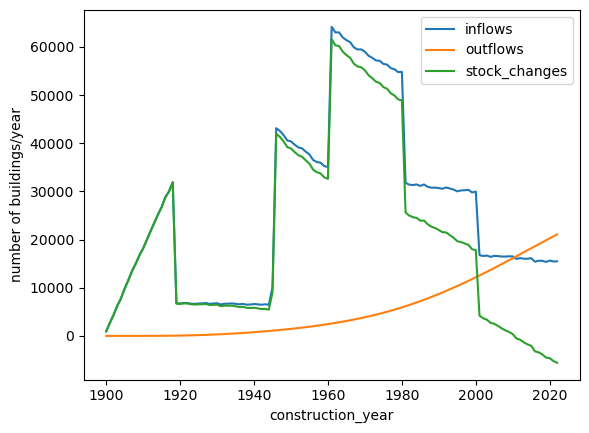

In [7]:
# %% 6. View the full MFA system
# plot flows
mfa_system[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'])

<Axes: xlabel='construction_year', ylabel='number of buildings'>

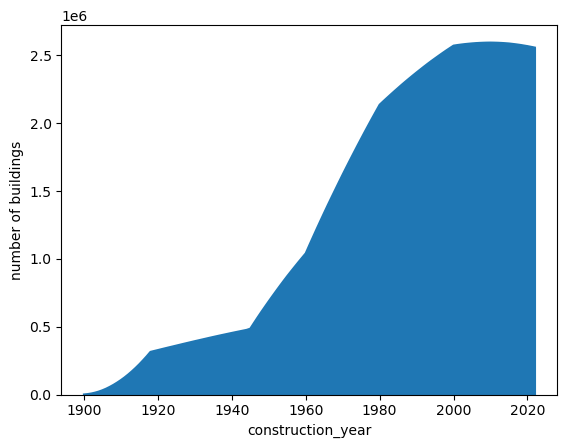

In [8]:
# plot stocks
mfa_system["stocks"].plot(kind="area", stacked=True, ylabel=units['stocks'])